<a href="https://colab.research.google.com/github/AlinaKruzhkova/University/blob/main/neural_networks/%22%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%963_%D0%A1%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D0%B5_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8_(CNN)_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Задание №1. Использование глубокой сверточной нейронной сети для классификации предметов одежды на примере датасета Fashion MNIST**


**В качестве интерфейса для работы с моделями используйте [Streamlit](https://colab.research.google.com/drive/1PUvx9rGgAYSb2dZfGbzjfqRK86CLzsko#scrollTo=kSbmm9EjH5Uz)**

[Техническая документация по датасету](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

## 1.1. Устанавливаем необходимые зависимости

In [ ]:
from keras.datasets import fashion_mnist # импорт исходного датасета
from keras.models import Sequential

from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

from keras.optimizers import Adam, SGD
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from tensorflow import keras

## 1.2. Разделяем данные на обучающую и тестовую выборку

In [ ]:
(trainX, trainy), (testX, testy) = fashion_mnist.load_data()

print('Train: X = ', trainX.shape)
print('Test: X = ', testX.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: X =  (60000, 28, 28)
Test: X =  (10000, 28, 28)


In [ ]:
trainX = trainX.astype('float32') / 255.0
testX = testX.astype('float32') / 255.0

# Добавляем канал для CNN (grayscale: 1 канал)
trainX = np.expand_dims(trainX, axis=-1)
testX = np.expand_dims(testX, axis=-1)

print('Train: X = ', trainX.shape)  # (60000, 28, 28, 1)
print('Test: X = ', testX.shape)    # (10000, 28, 28, 1)

Train: X =  (60000, 28, 28, 1)
Test: X =  (10000, 28, 28, 1)


## 1.3. Визуализируем часть данных из датасета

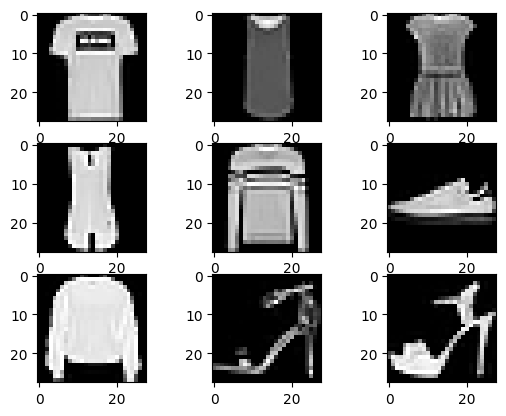

In [ ]:
for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(trainX[i], cmap=plt.get_cmap('gray'))

plt.show()

## 1.4. Создаём архитектуру нейронной сети и компилируем модель

In [ ]:
model = keras.Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10,  activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 1.5. Обучаем модель

In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_fashion_mnist.keras', monitor='val_accuracy', save_best_only=True)
]

In [ ]:
EPOCH = 30

model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [ ]:
his = model.fit(trainX, trainy,
                    batch_size=64,
                    epochs=EPOCH,
                    validation_split=0.2,
                    callbacks=callbacks,
                    verbose=1)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8156 - loss: 0.5126 - val_accuracy: 0.8743 - val_loss: 0.3525
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8784 - loss: 0.3363 - val_accuracy: 0.8826 - val_loss: 0.3270
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8941 - loss: 0.2919 - val_accuracy: 0.8963 - val_loss: 0.2921
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9046 - loss: 0.2587 - val_accuracy: 0.9021 - val_loss: 0.2691
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9128 - loss: 0.2356 - val_accuracy: 0.9086 - val_loss: 0.2591
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9219 - loss: 0.2125 - val_accuracy: 0.9087 - val_loss: 0.2523
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9286 - loss: 0.1929 - val_accuracy: 0.9058 - val_loss: 0.2637
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9355 - loss: 0.1753 - val_accuracy: 0.

In [ ]:
model = keras.models.load_model('best_fashion_mnist.keras')

## 1.6. Анализируем обученную модель. Строим график (графики) обучения

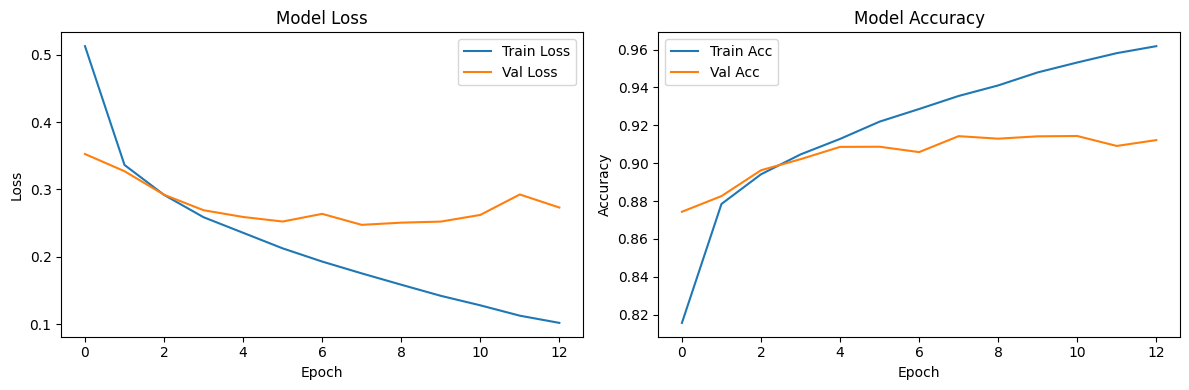

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(his.history['loss'], label='Train Loss')
plt.plot(his.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(his.history['accuracy'], label='Train Acc')
plt.plot(his.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## 1.7. Загружаем свои изображения. С помощью функции predict() получаем предсказание нейронной сети



> Требуется получить предсказания минимум по 5 изображениям, каждое из которых относится к разному классу. Не забудьте добавить метки к каждому классу (для этого можно просто создать список строк, каждая из которых будет соответствовать классу с определенным индексом см. [тех.док.](https://www.kaggle.com/datasets/zalando-research/fashionmnist)). Процент уверенности нейронной сети в своём предсказании выводить обязательно.



In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step


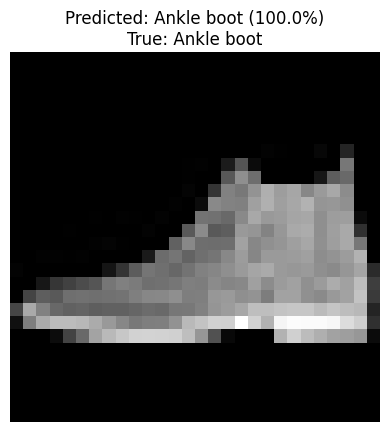

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


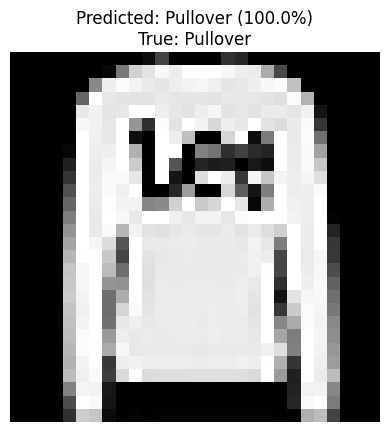

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


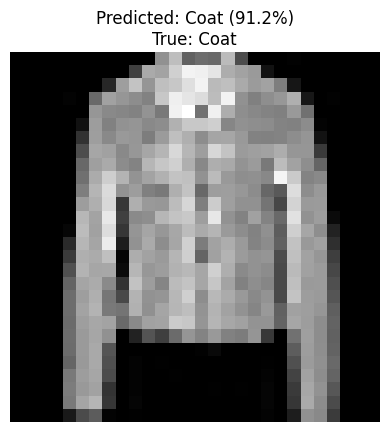

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


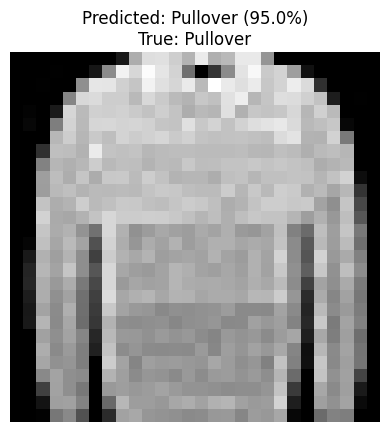

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


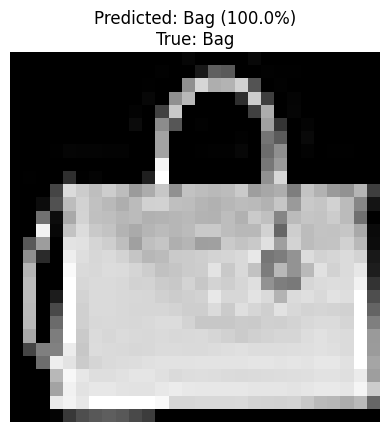

In [ ]:
# Тест на 5 разных классах из testX (пример: индексы с разными метками)
indices = [0, 1, 10, 20, 30]  # Подберите для разных testy[i]
for i in indices:
    img = testX[i]
    pred = model.predict(np.expand_dims(img, axis=0))[0]
    predicted_class = class_names[np.argmax(pred)]
    confidence = np.max(pred) * 100
    true_class = class_names[testy[i]]

    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f'Predicted: {predicted_class} ({confidence:.1f}%)\nTrue: {true_class}')
    plt.axis('off')
    plt.show()

# **Задание №2. Использование глубокой сверточной нейронной сети для классификации изображений по своему датасету**


## 2.1.  Используя датасет, собранный для предыдущей работы, разработайте и обучите **свою** модель глубокой  **сверточной** нейронной сети для классификации изображений







In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/NN"
IMAGE_SIZE = (128, 128)

In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from keras.models import Sequential
from keras.layers import Dense, Conv2D
from keras.optimizers import SGD, Adam
from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import random
import pickle
import cv2
import os
from google.colab.patches import cv2_imshow

In [ ]:
# Инициализация данных
data = []
labels = []

# Перебор классов
class_names = sorted(os.listdir(DATASET_PATH))
print(f"Классы: {class_names}")

for class_name in class_names:
    class_path = os.path.join(DATASET_PATH, class_name)
    image_paths = list(paths.list_images(class_path))

    # Берем первые 1000 изображений каждого класса
    image_paths = image_paths[:1010]

    for img_path in image_paths:
        # Загрузка и предобработка
        image = cv2.imread(img_path)
        image = cv2.resize(image, IMAGE_SIZE)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        data.append(image)
        labels.append(class_name)

print(f"Загружено {len(data)} изображений")

Классы: ['cat', 'rabbit', 'snake']
Загружено 3030 изображений


In [ ]:
# Нормализация в [0, 1]
data = np.array(data, dtype="float") / 255.0
labels = np.array(labels)
print(f"Форма данных: {data.shape}, метки: {labels.shape}")

(trainX, testX, trainY, testY) = train_test_split(data, labels,
                                                  test_size=0.25,
                                                  stratify=labels,
                                                  random_state=42)

lb = LabelBinarizer()
trainY = lb.fit_transform(trainY)
testY = lb.transform(testY)

print(f"Обучающая выборка: {trainX.shape}")
print(f"Тестовая выборка: {testX.shape}")

Форма данных: (3030, 128, 128, 3), метки: (3030,)
Обучающая выборка: (2272, 128, 128, 3)
Тестовая выборка: (758, 128, 128, 3)


## 2.2.   Ознакомьтесь с архитектурами сверточных нейронных сетей:

![Текст ссылки](https://velog.velcdn.com/images%2Fimfromk%2Fpost%2Fc04b189d-29cb-405d-93d0-b98dec818517%2Fimage.png)

На основе рассмотренных архитектур, реализуйте (частично повторяя основные паттерны проектирования) и обучите модель сверточной нейронной сети. Укажите архитектуру, которой Вы "вдохновились"

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3), kernel_regularizer=l2(0.01)),
    Conv2D(32, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    MaxPooling2D((2,2)),

    Conv2D(96, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    Conv2D(96, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(3, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 58, 58, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 27, 27, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 13824)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,769,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,973,987 (7.53 MB)

 Trainable params: 1,973,987 (7.53 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BS = 128
EPOCHS = 25

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ModelCheckpoint("model_minimal.keras", monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, min_delta=0.001),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-8, verbose=1)
]

In [ ]:
history = model.fit(
    trainX, trainY,
    validation_data=(testX, testY),
    batch_size=BS,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3441 - loss: 6.7844   
Epoch 1: val_accuracy improved from None to 0.36412, saving model to model_minimal.keras

Epoch 1: finished saving model to model_minimal.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.3323 - loss: 6.7650 - val_accuracy: 0.3641 - val_loss: 6.7193 - learning_rate: 1.0000e-05
Epoch 2/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.3740 - loss: 6.6985
Epoch 2: val_accuracy did not improve from 0.36412
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step - accuracy: 0.3583 - loss: 6.6800 - val_accuracy: 0.3259 - val_loss: 6.6359 - learning_rate: 1.0000e-05
Epoch 3/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.3414 - loss: 6.6165
Epoch 3: val_accuracy did not improve from 0.36412
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - accuracy: 0.3327 - loss: 6.5972 - val_accuracy: 0.3325 - val_loss: 6.5538 - learning_rate: 1.0000e-05
Epoch 4/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy:

In [ ]:
model.evaluate(testX, testY)

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.6253 - loss: 4.9751


[4.975109100341797, 0.6253297924995422]

## 2.3. Сохраните полученные модели

In [ ]:
model.load_weights("model_minimal.keras")

In [ ]:
predictions = model.predict(testX)
print(classification_report(testY.argmax(axis=1),
                          predictions.argmax(axis=1),
                          target_names=class_names))

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step
              precision    recall  f1-score   support

         cat       0.65      0.52      0.58       252
      rabbit       0.56      0.56      0.56       253
       snake       0.67      0.80      0.73       253

    accuracy                           0.63       758
   macro avg       0.62      0.63      0.62       758
weighted avg       0.62      0.63      0.62       758



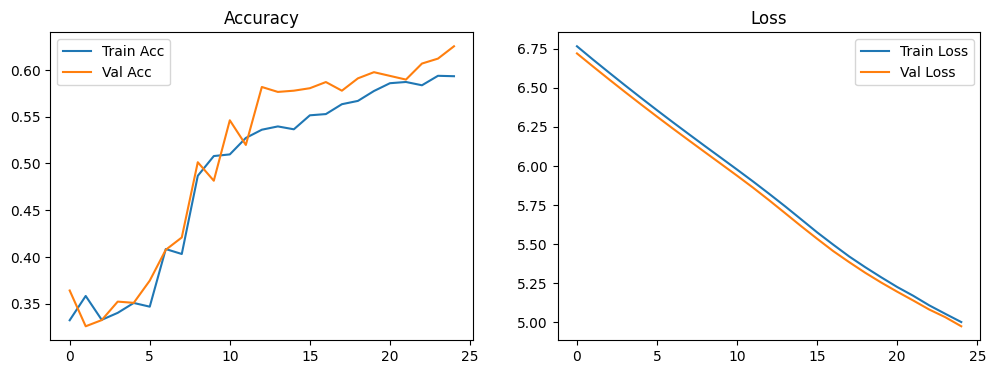

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
def preprocess_image(image):
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    image = cv2.resize(image, IMAGE_SIZE)
    image = image.astype("float") / 255.0
    image = np.expand_dims(image, axis=0)
    return image

def predict_image(image):
    processed = preprocess_image(image)
    predictions = model.predict(processed)[0]
    class_idx = np.argmax(predictions)
    confidence = predictions[class_idx] * 100

    return {
        class_names[class_idx]: f"{confidence:.1f}%",
        'all': dict(zip(class_names, [f"{p*100:.1f}%" for p in predictions]))
    }

In [ ]:
model.save('/content/drive/MyDrive/Colab Notebooks/final_image_classifier_cnn.keras')
# Сохранение меток классов
with open('/content/drive/MyDrive/Colab Notebooks/lb_cnn.pickle', 'wb') as f:
    pickle.dump(lb, f)
with open('/content/drive/MyDrive/Colab Notebooks/class_names_cnn.txt', 'w') as f:
    f.write('\n'.join(class_names))
print(" Модель сохранена!")

 Модель сохранена!


## 2.4. Загрузите обученную модель из прошлой практической работы


In [ ]:
from tensorflow.keras.models import load_model

# Модель 1 (оригинальная) - уже загружена
model_cl = load_model("/content/drive/MyDrive/Colab Notebooks/final_image_classifier.keras")
print("Model 1 loaded")

# Модель 2 (с Dropout/BatchNorm) - если сохранили
try:
    model_cnn = load_model("/content/drive/MyDrive/Colab Notebooks/final_image_classifier_cnn.keras")
    print("Model 2 loaded")
except:
    print("Model 2 not found")

Model 1 loaded
Model 2 loaded



## 2.5. Сравните между собой точной всех трёх моделей, подавая на вход одинаковые изображения (15 разных изображений). Сравните предсказания каждой из моделей и сделайте выводы

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Берём первые 15 изображений из testX
test_images = testX[:15]
true_labels = testY[:15]

class_names = ['cat', 'rabbit', 'snake']

predictions = {}
models = {'Model1': model_cl}
if 'model2' in locals(): models['Model2'] = model_cnn

# Предсказания всех моделей
for name, model in models.items():
    preds = model.predict(test_images, verbose=0)
    predictions[name] = preds

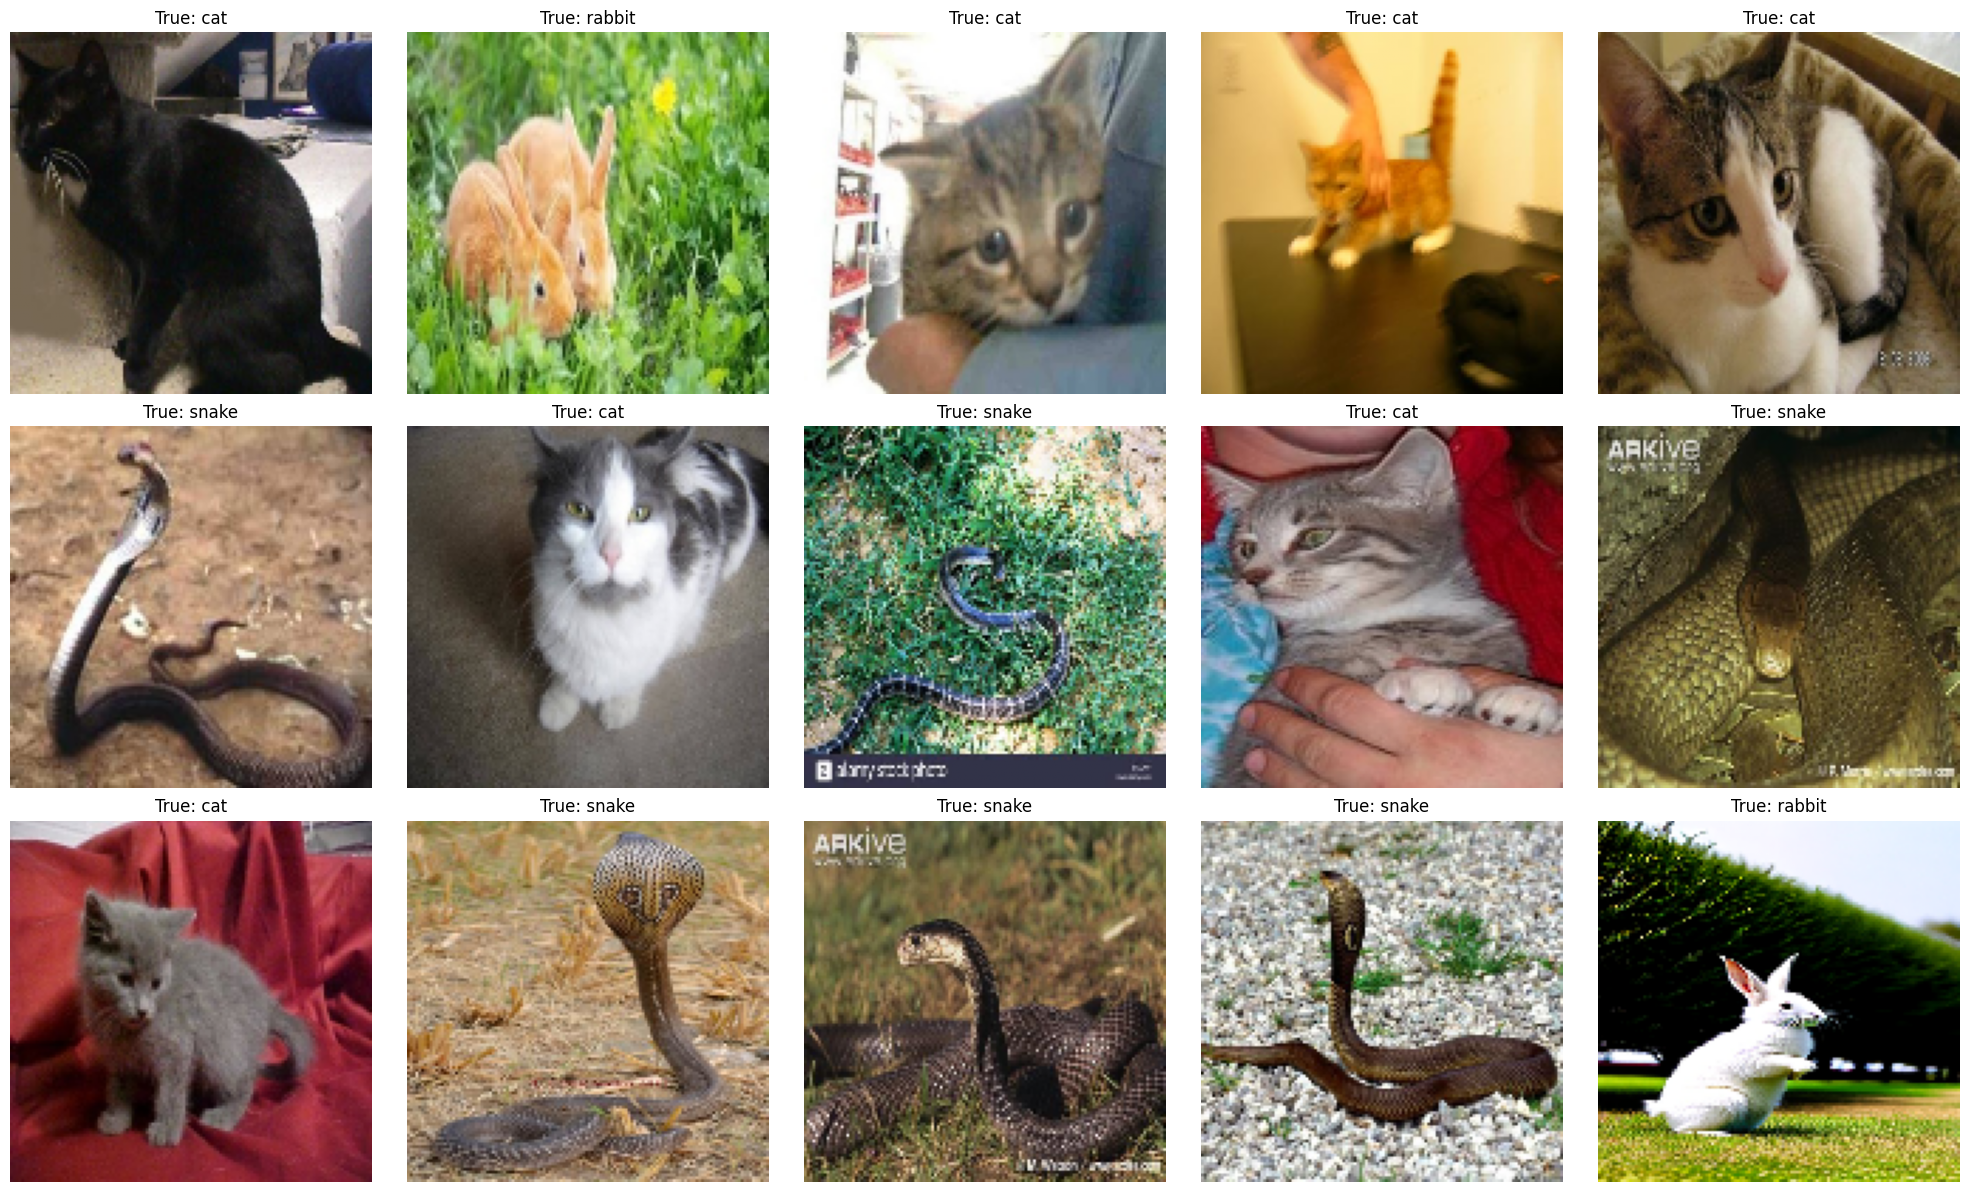

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.ravel()

for i in range(15):
    # Истинный класс
    true_class = np.argmax(true_labels[i])

    # Показываем изображение
    axes[i].imshow(test_images[i])
    axes[i].set_title(f"True: {class_names[true_class]}")
    axes[i].axis('off')

    # Подписи предсказаний моделей
    pred_text = []
    for name, probs in predictions.items():
        pred_class = np.argmax(probs[i])
        confidence = np.max(probs[i])
        correct = '' if pred_class == true_class else ''
        pred_text.append(f"{name}: {class_names[pred_class]} ({confidence:.1%}) {correct}")

    axes[i].set_xlabel('\n'.join(pred_text), fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
results = {}
for name, probs in predictions.items():
    pred_classes = np.argmax(probs, axis=1)
    true_classes = np.argmax(true_labels, axis=1)
    accuracy = np.mean(pred_classes == true_classes)
    results[name] = accuracy

print("Точность на 15 изображениях:")
for name, acc in results.items():
    print(f"{name}: {acc:.2%} ({acc*15:.0f}/15 правильных)")

Точность на 15 изображениях:
Model1: 53.33% (8/15 правильных)


# **Задание №3. Использование глубокой сверточной нейронной сети для восстановления изображения**

## 3.1. Работа с данными

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

### 3.1.1. Переведите векторы в настоящие изображения из двух размерностей

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [ ]:
train.shape

(320, 4096)

Сейчас изображение - это вектор, имеющий размерность 4096.

In [ ]:
# Ваш код здесь

train = train.reshape((train.shape[0], 64, 64))
test = test.reshape((test.shape[0], 64, 64))

test.shape

(80, 64, 64)

### 3.1.2. Отрисуйте несколько примеров

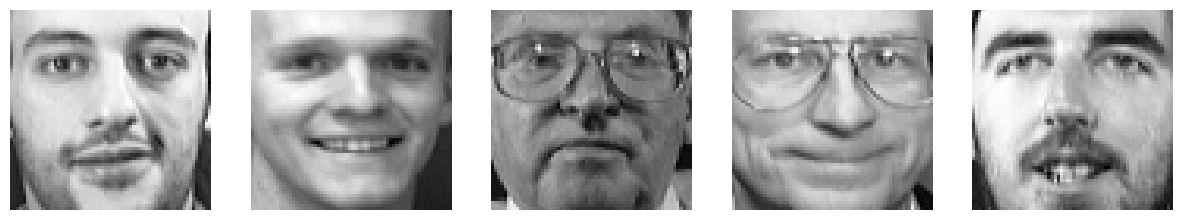

In [ ]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(train[i], cmap='gray')
    ax[i].axis('off')

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [ ]:
n_pixels = train.shape[1]

# Upper half of the faces
X_train = train[:, :(n_pixels + 1) // 2, :]
# Lower half of the faces
y_train = train[:, n_pixels // 2:, :]


X_test = test[:, :(n_pixels + 1) // 2, :]
y_test = test[:, n_pixels // 2:, :]

In [ ]:
X_train.shape

(320, 32, 64)

Вот один пример обучающей пары.

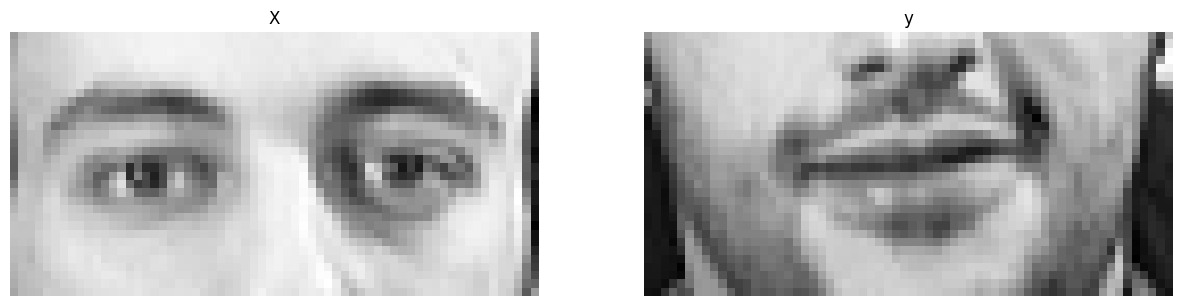

In [ ]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx], cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx], cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

### 3.1.3. Измените размерность y
Остается только изменить размерность y, т.к. сейчас $y$ - картинка 32x64, а выход нейронной сети у нас будет одномерный и равный 32 * 64 = 2048.

In [ ]:
y_train_n = y_train.reshape(y_train.shape[0], 32 * 64)
y_test_n = y_test.reshape(y_test.shape[0], 32 * 64)

y_train_n.shape

(320, 2048)

## 3.2. Создайте архитектуру для этой задачи

In [ ]:
model = models.Sequential([
    layers.Input(shape=(32, 64, 1)),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(2048, activation='sigmoid')
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 16, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 16, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 4, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 4, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 2, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2048)           │       526,336 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 885,888 (3.38 MB)

 Trainable params: 885,888 (3.38 MB)

 Non-trainable params: 0 (0.00 B)

## 3.3. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'adam'

In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

## 3.4. Обучите нейросеть

Выберите нужное количество эпох.


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
callbacks = [
    ModelCheckpoint("best_face_completion.keras",
                   monitor='val_loss', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

In [ ]:
X_train_norm = X_train.astype('float32')  # [0, 1]
y_train_norm = y_train_n.astype('float32')  # [0, 1]

X_test_norm = X_test.astype('float32')
y_test_norm = y_test_n.astype('float32')

# Добавляем канал для сверточных слоёв
X_train_c = X_train_norm.reshape((X_train_norm.shape[0], 32, 64, 1))
X_test_c = X_test_norm.reshape((X_test_norm.shape[0], 32, 64, 1))

# Перекомпилируем модель с подходящими параметрами
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(X_train_c, y_train_norm,
                   epochs=50,
                   batch_size=32,
                   validation_split=0.2,
                   callbacks=callbacks,
                   verbose=1)

Epoch 1/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - loss: 0.0260 - mae: 0.1308
Epoch 1: val_loss improved from None to 0.02441, saving model to best_face_completion.keras

Epoch 1: finished saving model to best_face_completion.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0261 - mae: 0.1316 - val_loss: 0.0244 - val_mae: 0.1267
Epoch 2/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0252 - mae: 0.1292
Epoch 2: val_loss improved from 0.02441 to 0.02184, saving model to best_face_completion.keras

Epoch 2: finished saving model to best_face_completion.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0217 - mae: 0.1190 - val_loss: 0.0218 - val_mae: 0.1197
Epoch 3/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0189 - mae: 0.1102
Epoch 3: val_loss improved from 0.02184 to 0.02150, saving model to best_face_completion.keras

Epoch 3: finished saving model to best_face_completion.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0206 - mae: 0.1157 - val_loss: 0.0215 - val

## 3.5. Сделайте предсказания на тестовых данных

In [ ]:
model.save('/content/drive/MyDrive/Colab Notebooks/best_face_completion_cnn.keras')
# Сохранение меток классов
with open('/content/drive/MyDrive/Colab Notebooks/best_face_completion_cnn.pickle', 'wb') as f:
    pickle.dump(lb, f)
with open('/content/drive/MyDrive/Colab Notebooks/best_face_completion_cnn.txt', 'w') as f:
    f.write('\n'.join(class_names))
print(" Модель сохранена!")

 Модель сохранена!


In [ ]:
model = tf.keras.models.load_model('best_face_completion.keras')

# Предсказание (возвращает значения в [0, 1] благодаря sigmoid на выходе)
preds_norm = model.predict(X_test_c)

# Конвертация в [0, 255] только для визуализации или метрик в исходном масштабе
preds_uint8 = (preds_norm * 255.0).astype('uint8')

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step


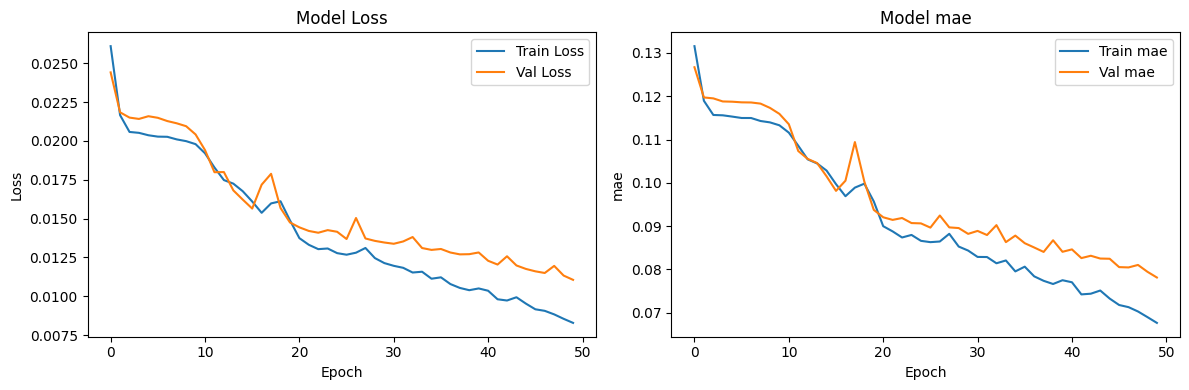

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train mae')
plt.plot(history.history['val_mae'], label='Val mae')
plt.title('Model mae')
plt.xlabel('Epoch')
plt.ylabel('mae')
plt.legend()

plt.tight_layout()
plt.show()

## 3.6. Посчитайте метрику качества на тестовых данных

In [ ]:
from sklearn.metrics import mean_absolute_error

# Считаем MAE в нормализованном пространстве [0, 1]
mae_normalized = mean_absolute_error(y_test_norm, preds_norm)
print(f'MAE (normalized [0,1]): {mae_normalized:.6f}')

# Или в исходном масштабе [0, 255]:
mae_original = mean_absolute_error(y_test_norm * 255, preds_norm * 255)
print(f'MAE (original scale [0,255]): {mae_original:.2f}')

MAE (normalized [0,1]): 0.077137
MAE (original scale [0,255]): 19.67


## 3.7. Преобразуйте предсказанные векторы в двумерное изображение (поменяйте их размерность)

In [ ]:
pred_test = preds_norm.reshape(preds_norm.shape[0], 32, 64)

Отрисуйте все предсказания.

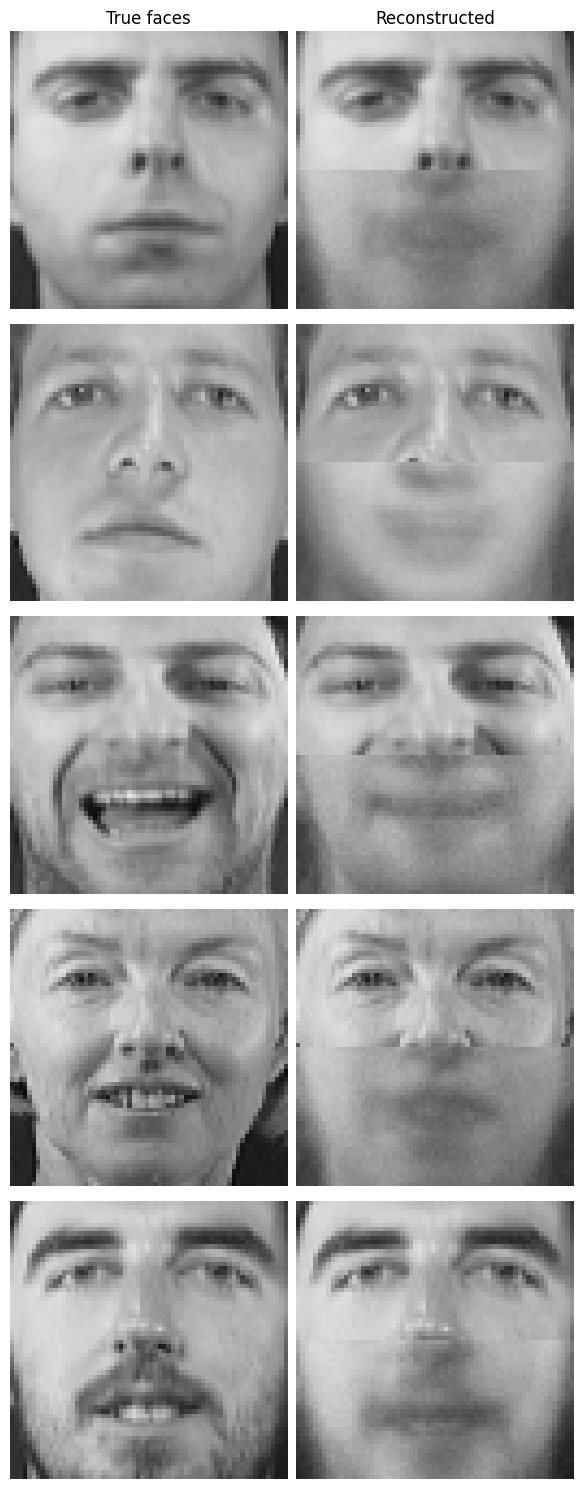

In [ ]:
n_faces = 5
n_cols = 2
plt.figure(figsize=(3 * n_cols, 3 * n_faces))

for i in range(n_faces):
    true_upper = X_test_norm[i]                  # (32, 64), [0,1]
    true_lower = y_test_norm[i].reshape(32, 64)  # (32, 64), [0,1]
    true_face = np.vstack((true_upper, true_lower))

    sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    if i == 0:
        sub.set_title("True faces")
    sub.axis("off")
    sub.imshow(true_face, cmap=plt.cm.gray, interpolation="nearest", vmin=0, vmax=1)

    # Реконструкция
    pred_lower = pred_test[i]  # [0,1]
    completed_face = np.vstack((true_upper, pred_lower))

    sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)
    if i == 0:
        sub.set_title("Reconstructed")
    sub.axis("off")
    sub.imshow(completed_face, cmap=plt.cm.gray, interpolation="nearest", vmin=0, vmax=1)

plt.tight_layout()
plt.show()

## 3.8. Предскажите нижнюю половину лица по верхей из загруженной Вами фото (лицо на фото может быть чье угодно)

Saving andrewg.jpg to andrewg (4).jpg
Загружено: andrewg (4).jpg


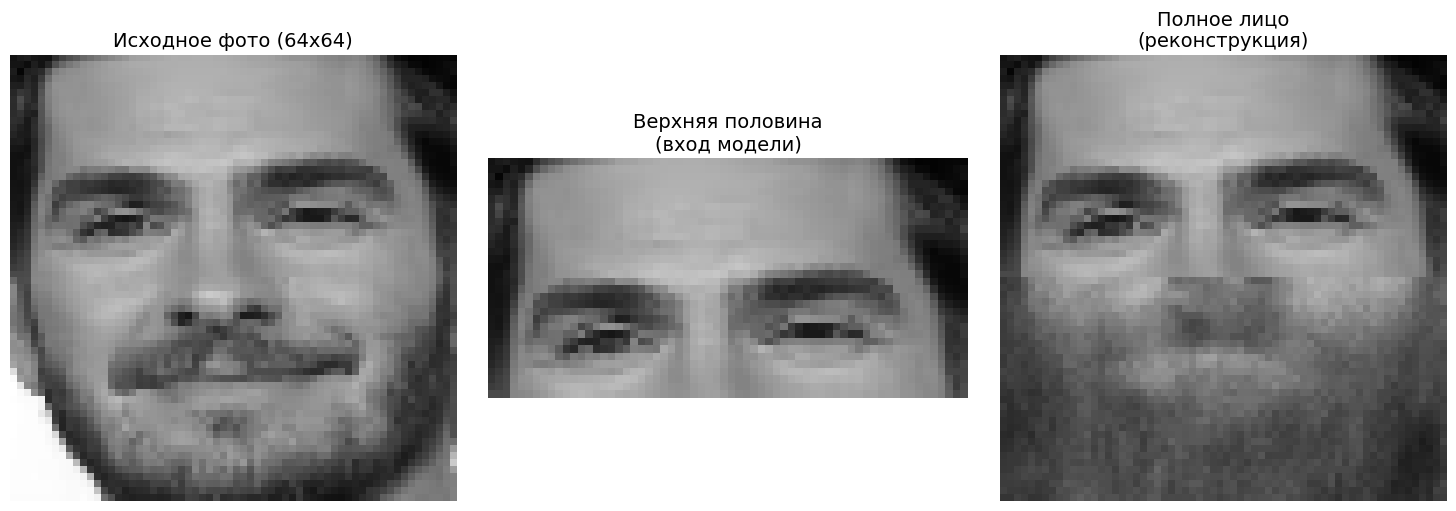

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Загрузка фото
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print(f"Загружено: {img_path}")

# Предобработка
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (64, 64)).astype('float32') / 255.0  # Нормализуем к [0, 1]

# Берём верхнюю половину
upper_half = img_resized[:32, :]  # (32, 64), [0, 1]
upper_input = upper_half.reshape(1, 32, 64, 1)  # (1, 32, 64, 1)

# Предсказание
lower_pred_norm = model.predict(upper_input, verbose=0)  # [0, 1]
lower_pred = lower_pred_norm.reshape(32, 64)  # [0, 1]

# Сборка полного лица
full_reconstructed = np.vstack((upper_half, lower_pred))  # [0, 1]

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_resized, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Исходное фото (64x64)', fontsize=14)
axes[0].axis('off')

axes[1].imshow(upper_half, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Верхняя половина\n(вход модели)', fontsize=14)
axes[1].axis('off')

axes[2].imshow(full_reconstructed, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Полное лицо\n(реконструкция)', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()